In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import visualize as vis, raw_scores
from hbn.models import manifold_learning as ml

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
vis.plotting_style()

In [47]:
## FUNCTIONS ## 

def filter_data(df, dx, target, development, sex, dx_to_include):
    """get raw scores for each question for either CBCL, YSR, TRF
    Args:
        dx: str
        target: str
        development: list
        dx_to_include: list
        df: pd.DataFrame
    returns:
        data (pd.DataFrame)
    """

    # filter dataframe
    df.loc[df['Age_round']<=10, 'development'] = 'young'
    df.loc[df['Age_round']>=11, 'development'] = 'old'
    df_grouped = df.groupby(['Identifiers', dx]).first().reset_index()
    df_grouped = df_grouped[(df_grouped[dx].isin(dx_to_include)) & \
                            (df_grouped['Sex'].isin(sex)) & \
                            (df_grouped['Age_round'].isin(np.arange(6,18))) & \
                            (df_grouped['development'].isin(development))].reset_index(drop=True)

    # get target
    labels = df_grouped[target].tolist()
    # target = df_grouped[target].factorize()[0]

    return df_grouped, labels


## MAIN ##
dx = 'DX_ADHD'
target = 'Sex'
assessment = 'Child'

# get data
df, questions = raw_scores.get_data(
    assessment=assessment, 
    dx=dx, 
    measure='C3SR',
    cols_to_filter=None,
    )

# get raw scores
data, labels = filter_data(
                        df=df,      
                        dx=dx, 
                        target=target,
                        development=['old'],
                        sex=['female', 'male'],
                        dx_to_include=['ADHD (all comorbid.)'],
                )

# get numeric cols
numeric_cols = data[questions].select_dtypes(include=['number']).columns
data = data[numeric_cols]



### 3D UMAP

In [48]:
# get UMAP embeddings for data
embedding = ml.calculate_embedding(
    data=data, 
    standarize=True, 
    n_components=3,
    n_neighbors=15,
    min_dist=0.01,
    )

# visualize embedding (3d display)
embedding_with_hue = pd.concat([pd.DataFrame(embedding), pd.DataFrame({'target': target, 'labels': labels})], axis=1)
ml.plot_umap_3d(embedding_with_hue, target='labels')


### 2D UMAP

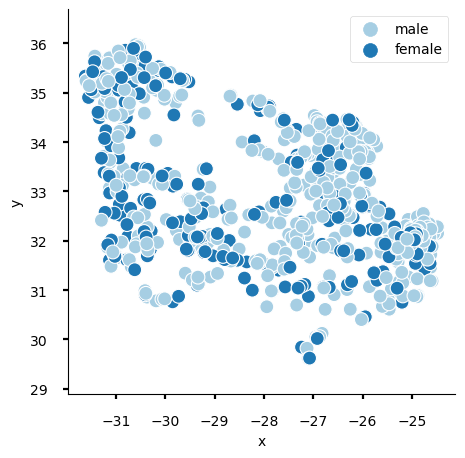

In [49]:
# get UMAP embeddings for data
embedding = ml.calculate_embedding(
    data=data, 
    standarize=True, 
    n_components=2,
    n_neighbors=15,
    min_dist=0.01,
    )

# visualize embedding (3d display)
embedding_with_hue = pd.concat([pd.DataFrame(embedding), pd.DataFrame({'target': target, 'labels': labels})], axis=1)
ml.plot_umap_2d(embedding_with_hue, target='labels')

